Это pandas DataFrame!
Это pandas DataFrame!


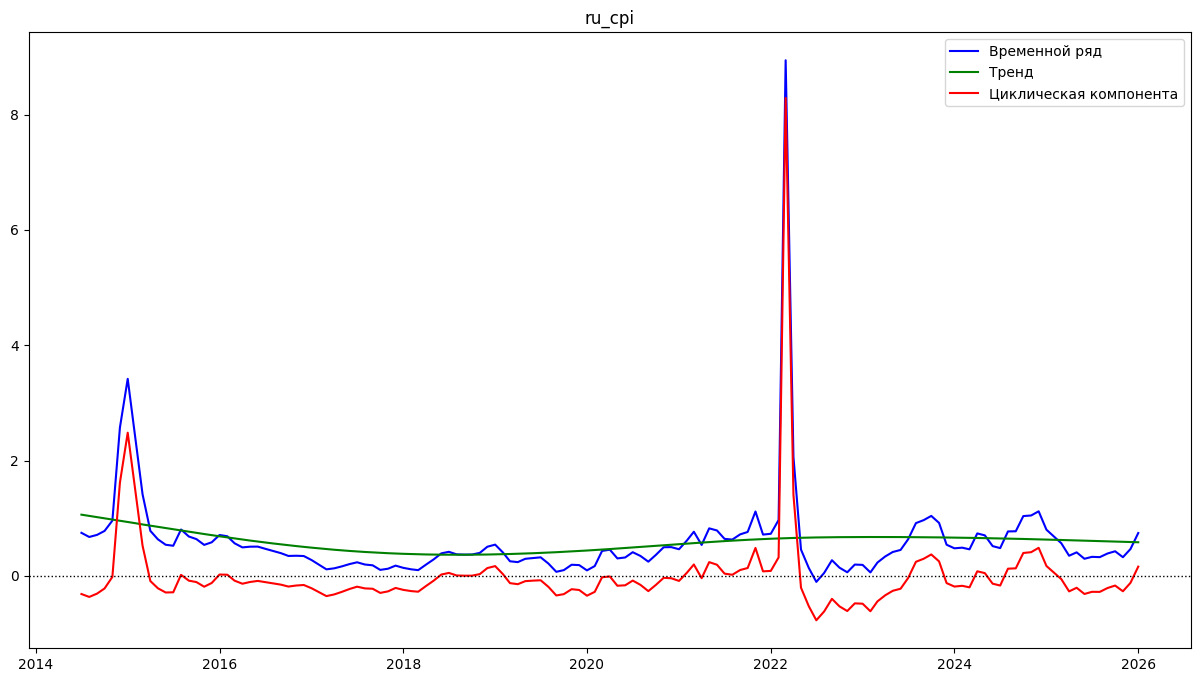

Исходный ряд ru_cpi оказался стационарным


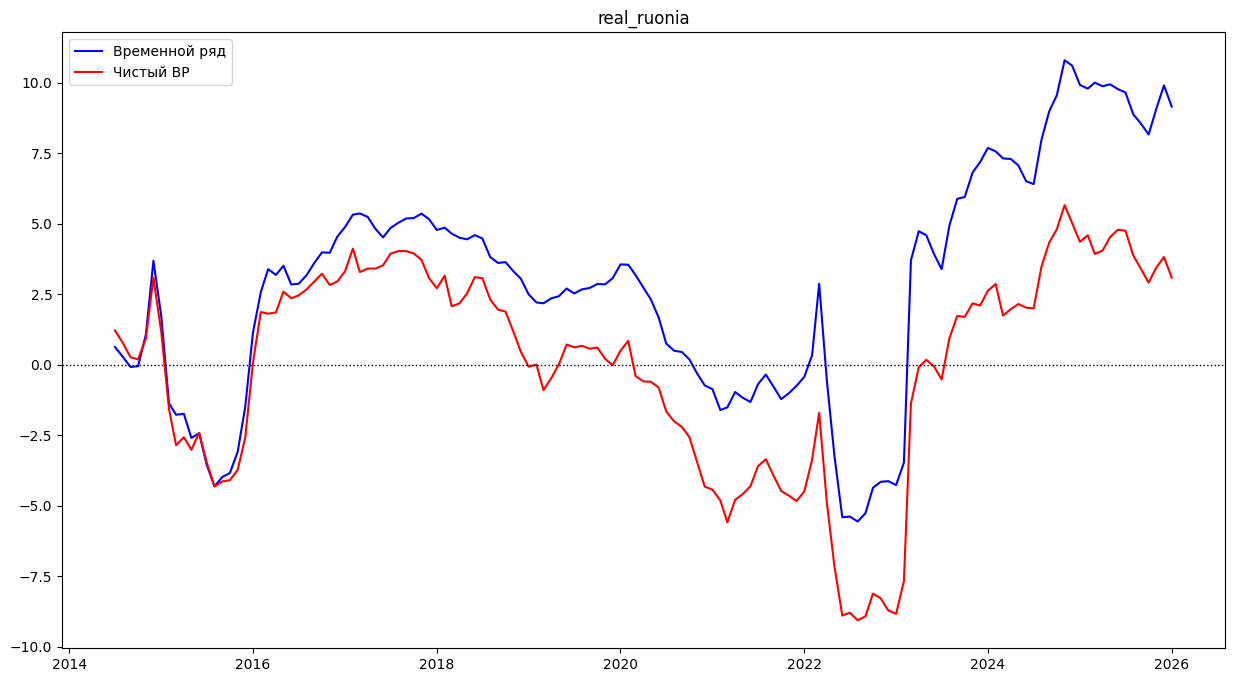

Исходный ряд real_ruonia оказался стационарным


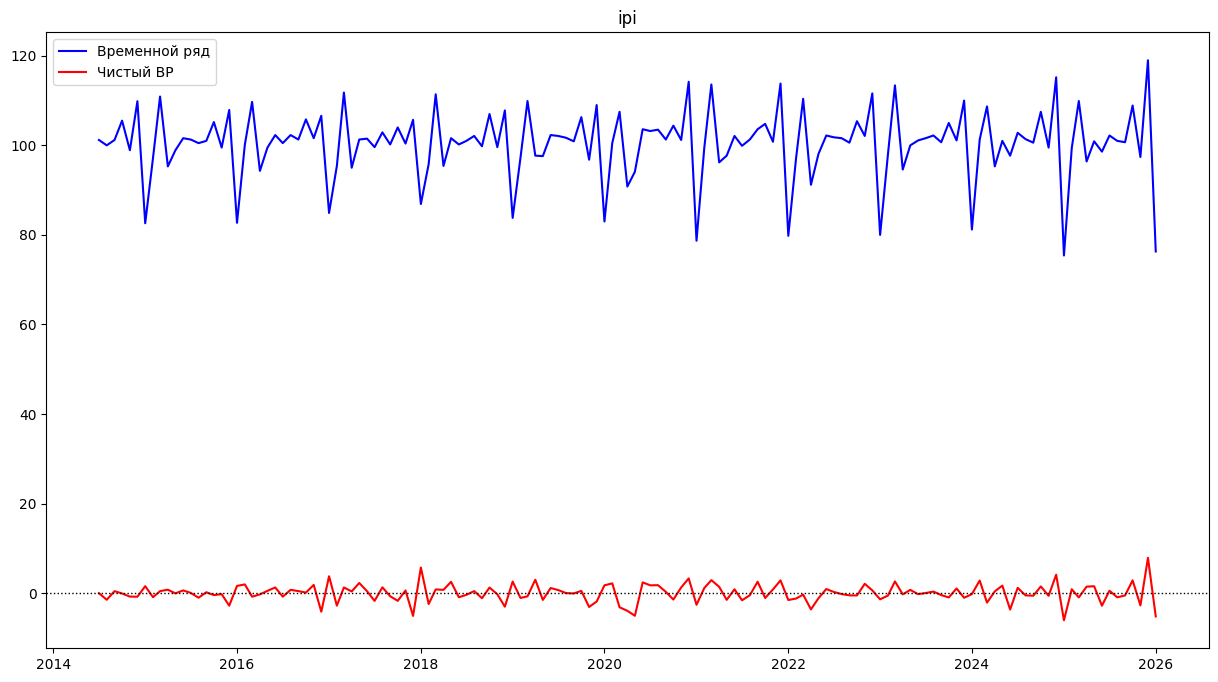

Исходный ряд ipi оказался стационарным


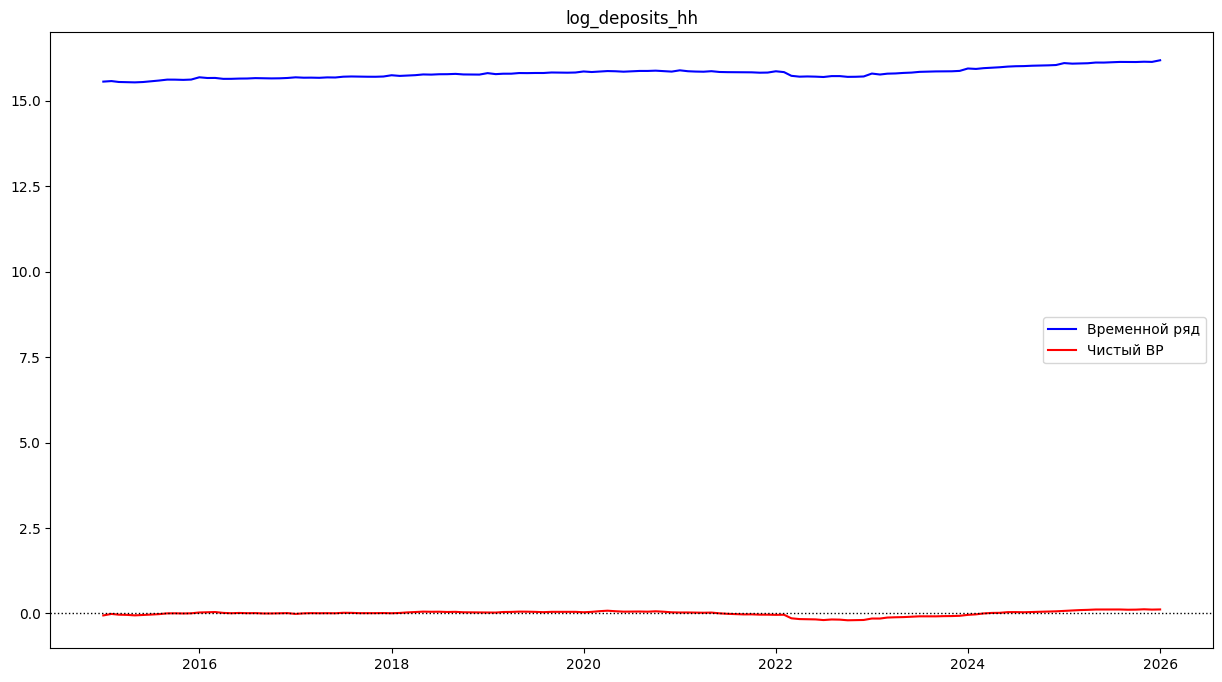

Исходный ряд log_deposits_hh оказался стационарным


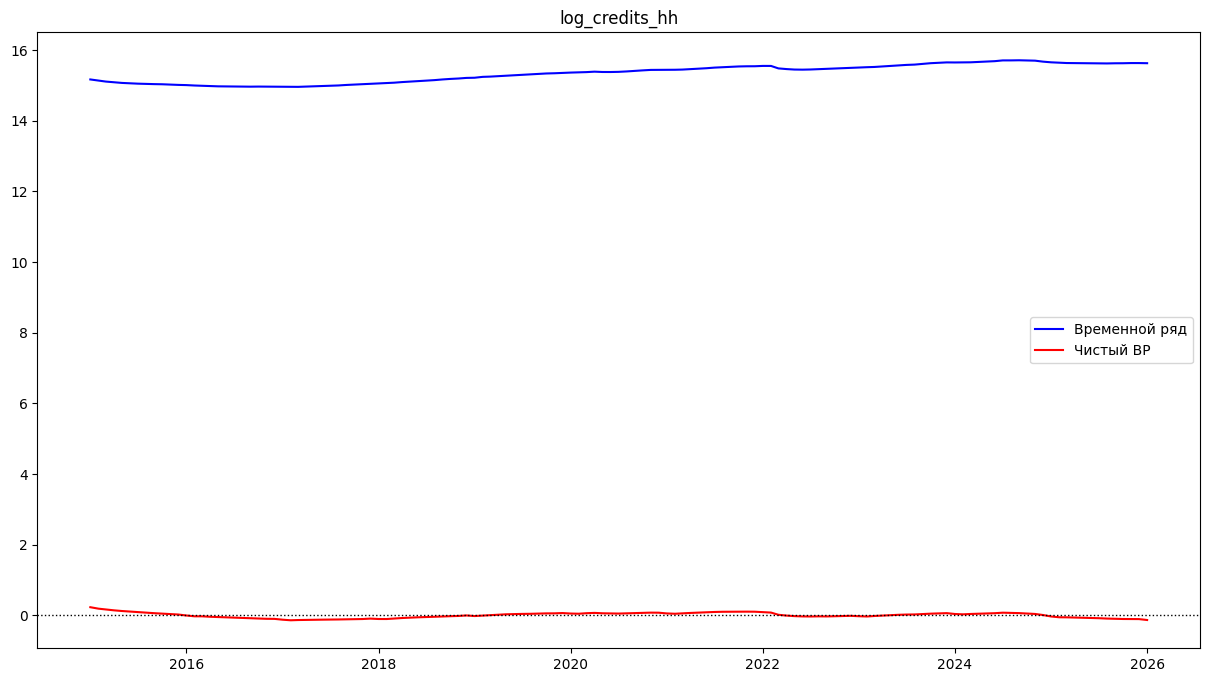

Исходный ряд log_credits_hh оказался стационарным


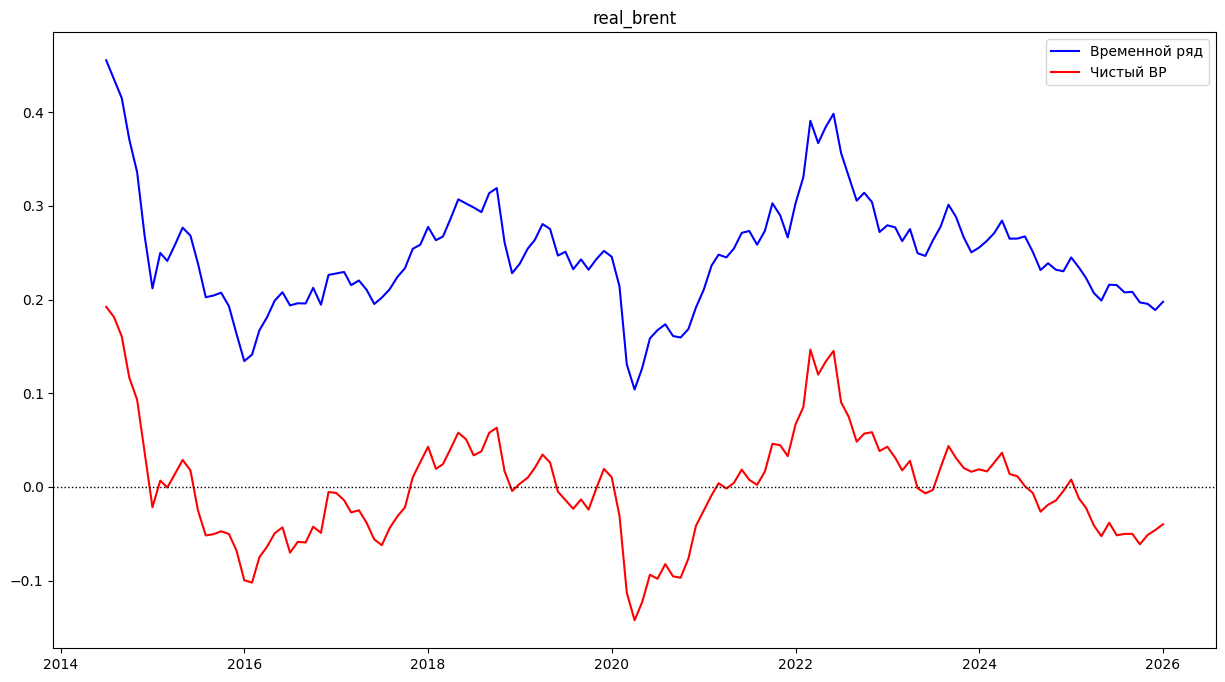

Исходный ряд real_brent оказался стационарным


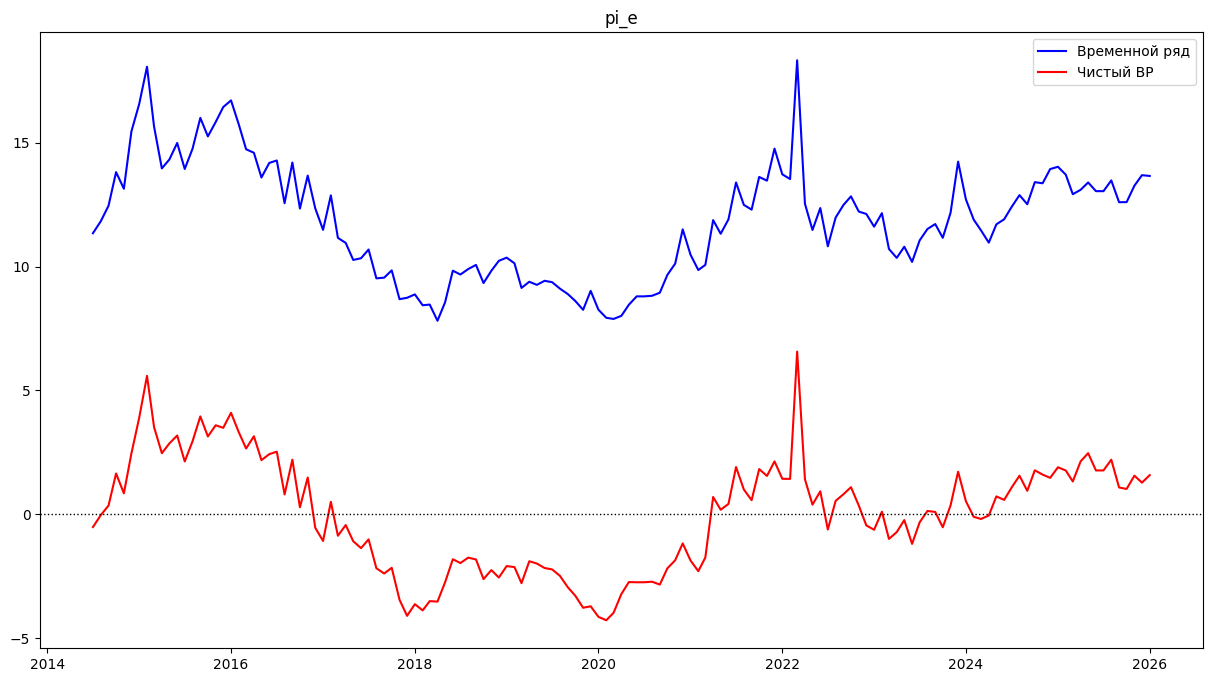

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


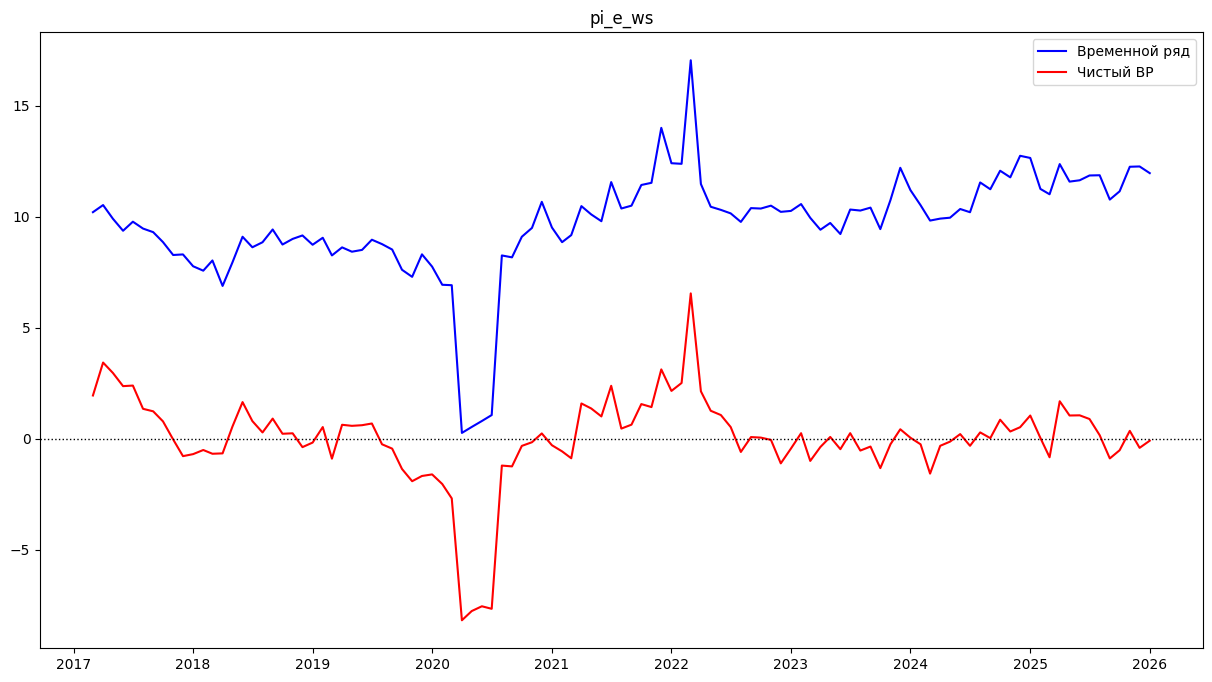

Исходный ряд pi_e_ws оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


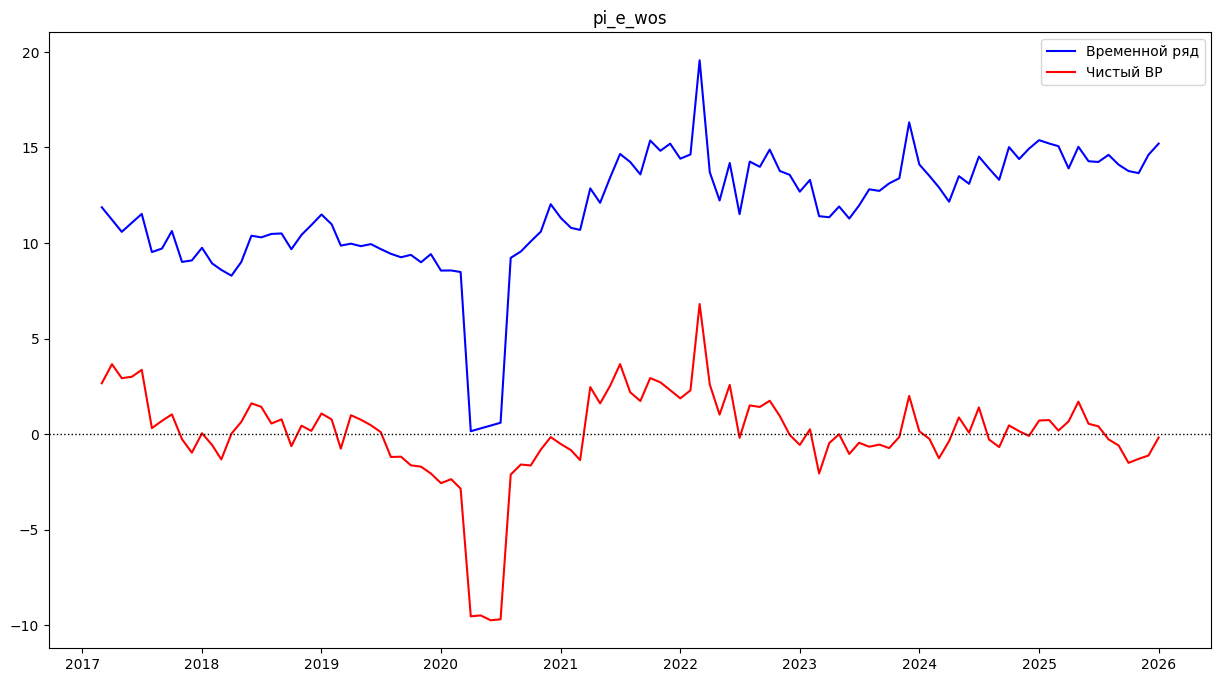

Исходный ряд pi_e_wos оказался стационарным


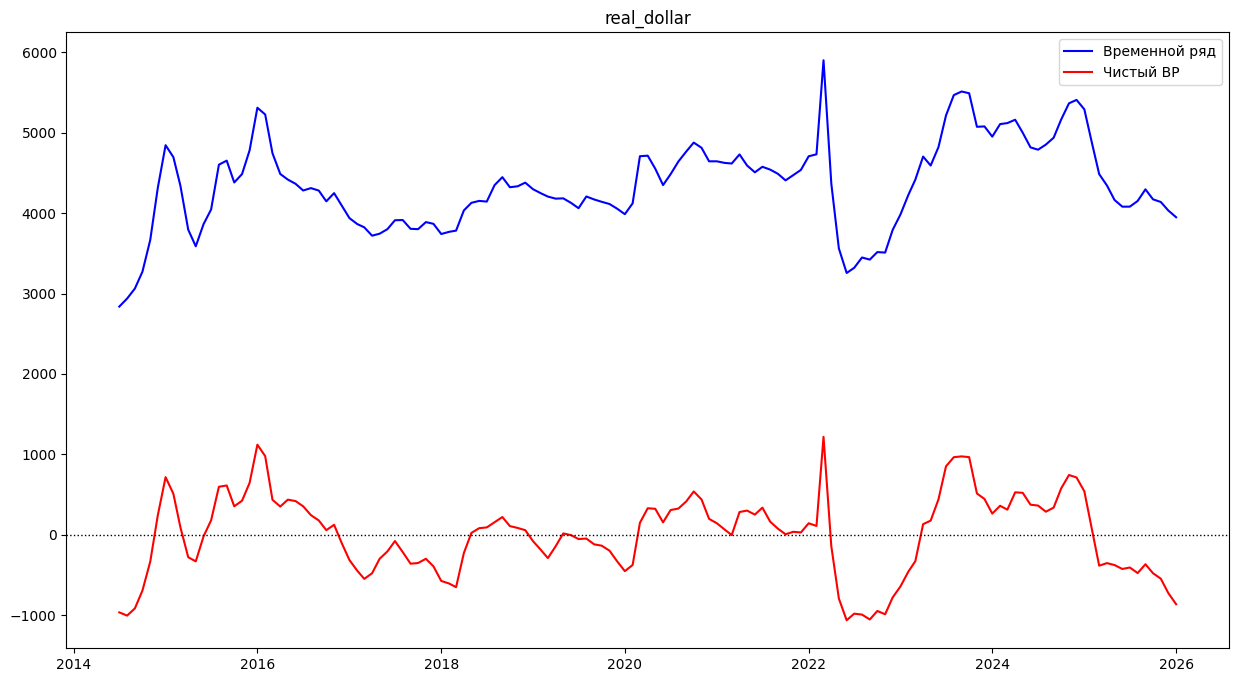

Исходный ряд real_dollar оказался стационарным


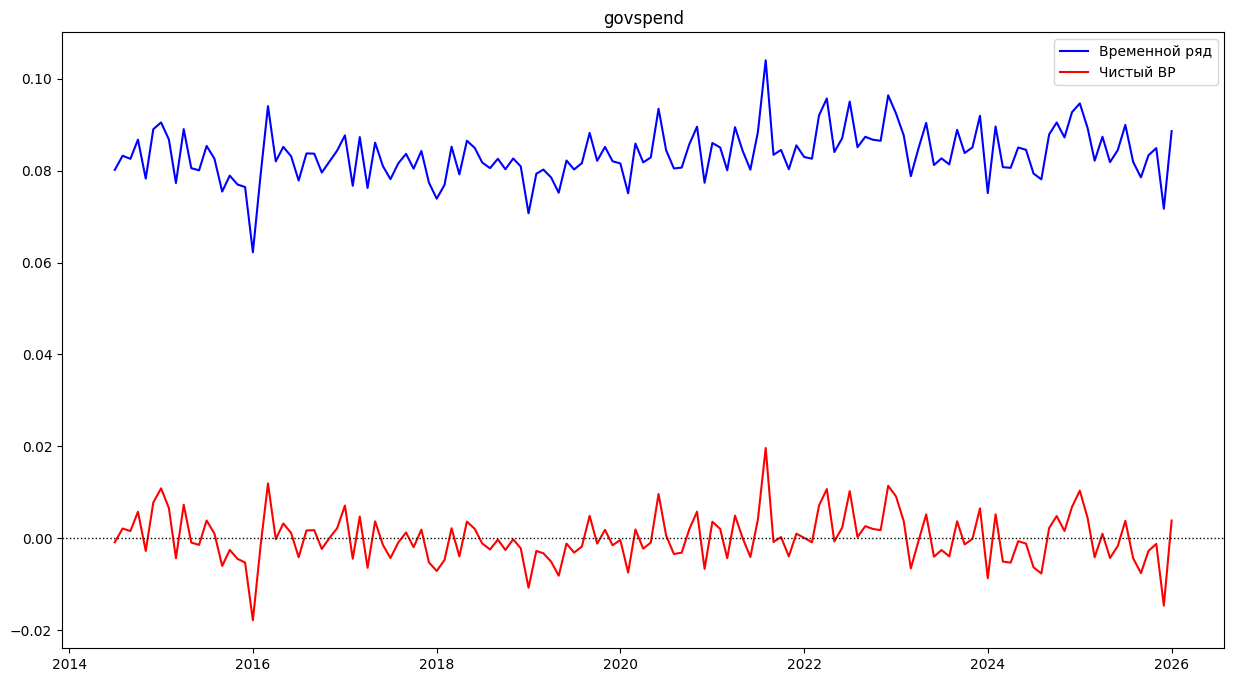

Исходный ряд govspend оказался стационарным


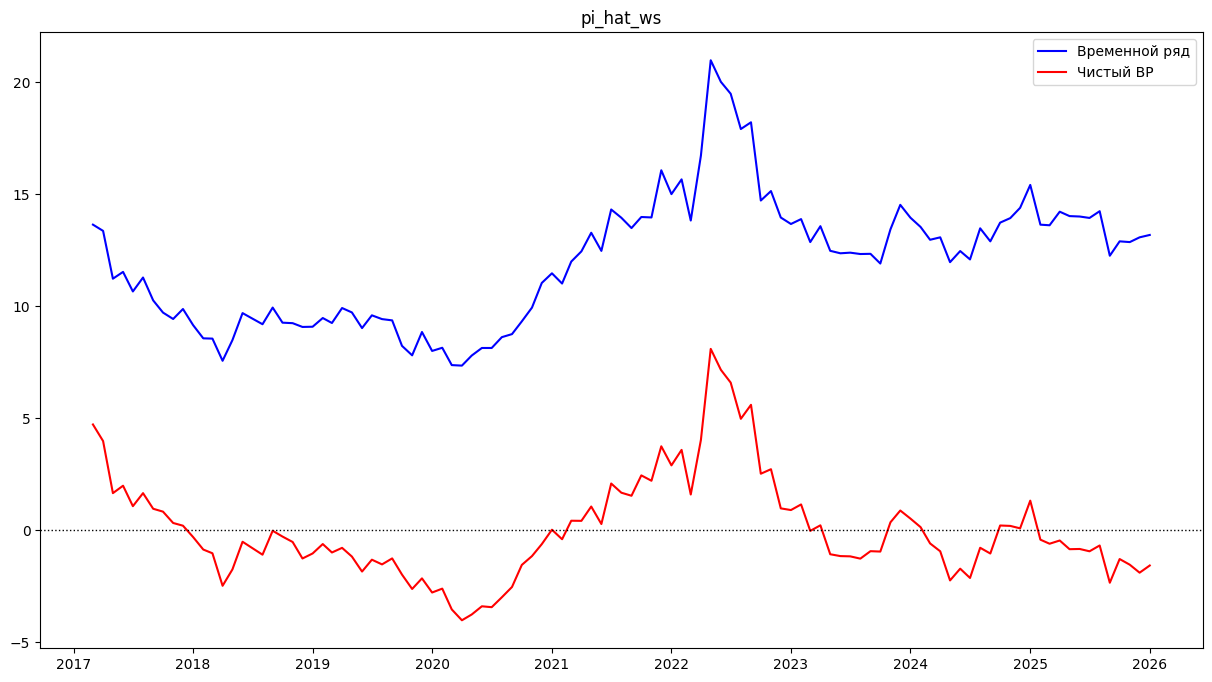

Исходный ряд pi_hat_ws оказался стационарным


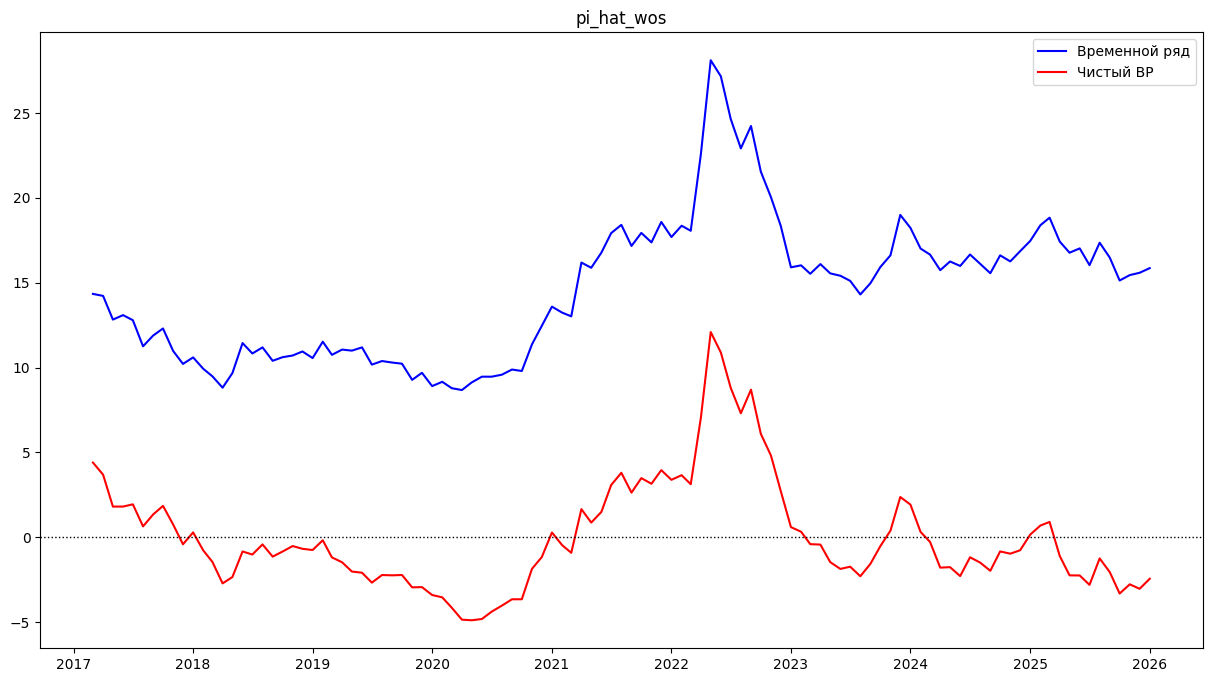

Исходный ряд pi_hat_wos оказался стационарным


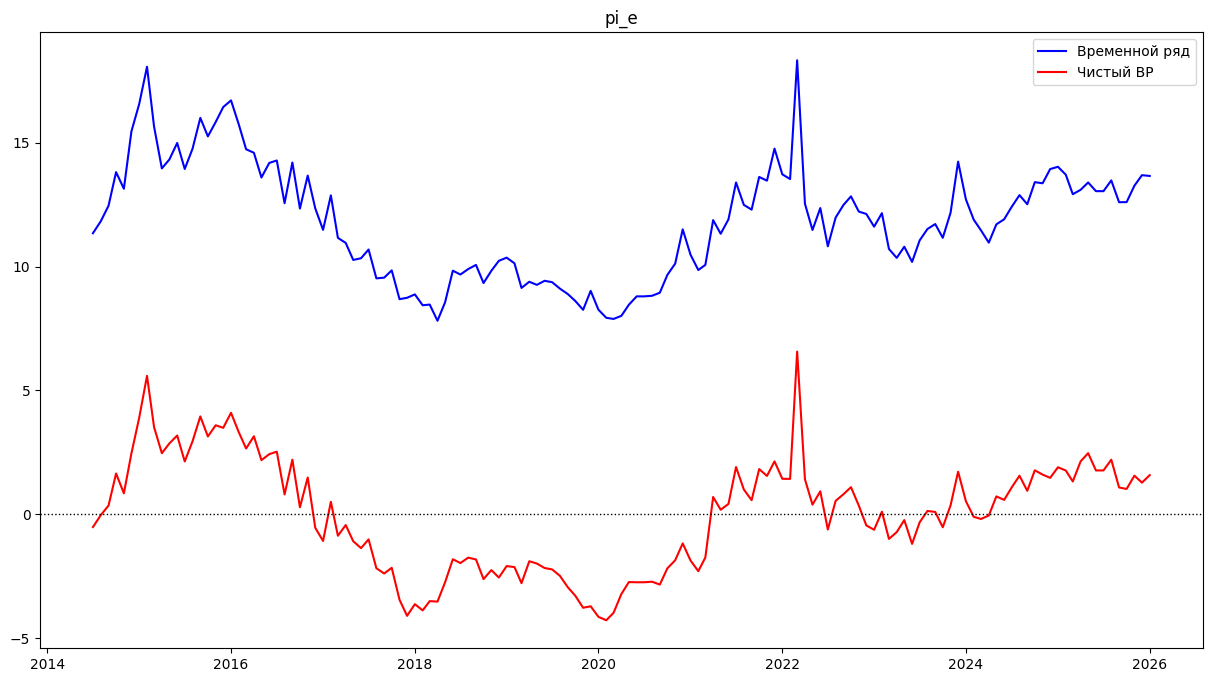

Исходный ряд pi_e оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


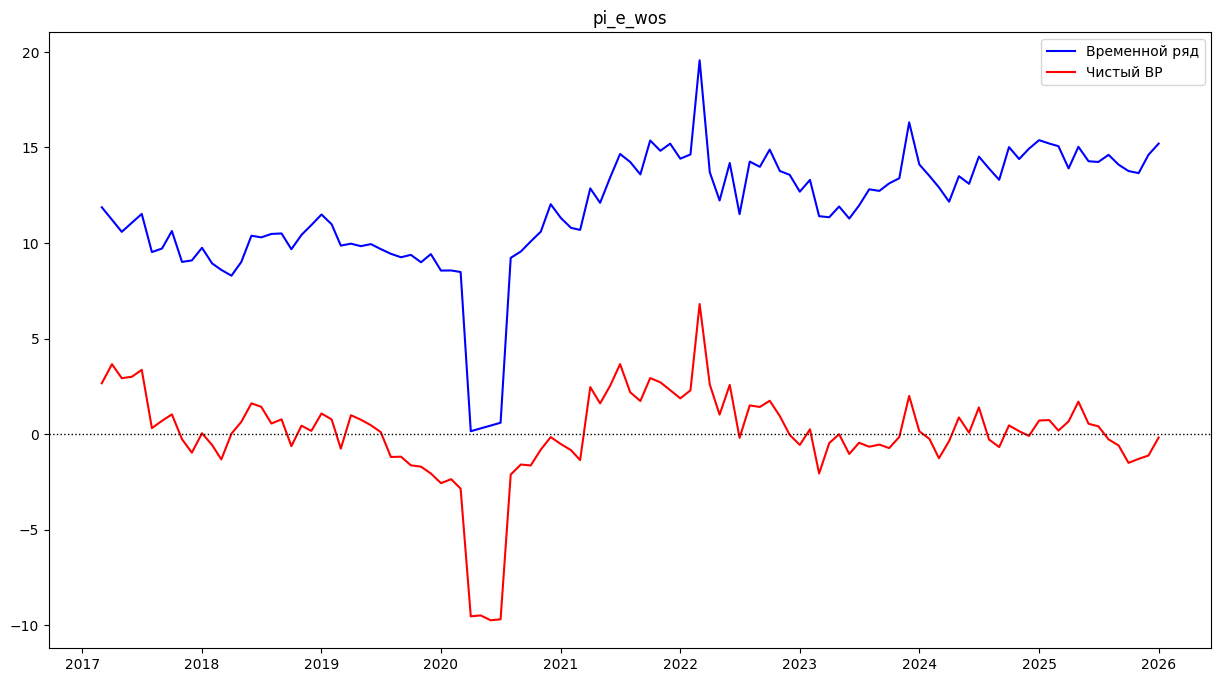

Исходный ряд pi_e_wos оказался стационарным
Обрати внимание, что для переменной var_name есть пробел в данных
между 73 и 68 наблюдениями длинной больше 2


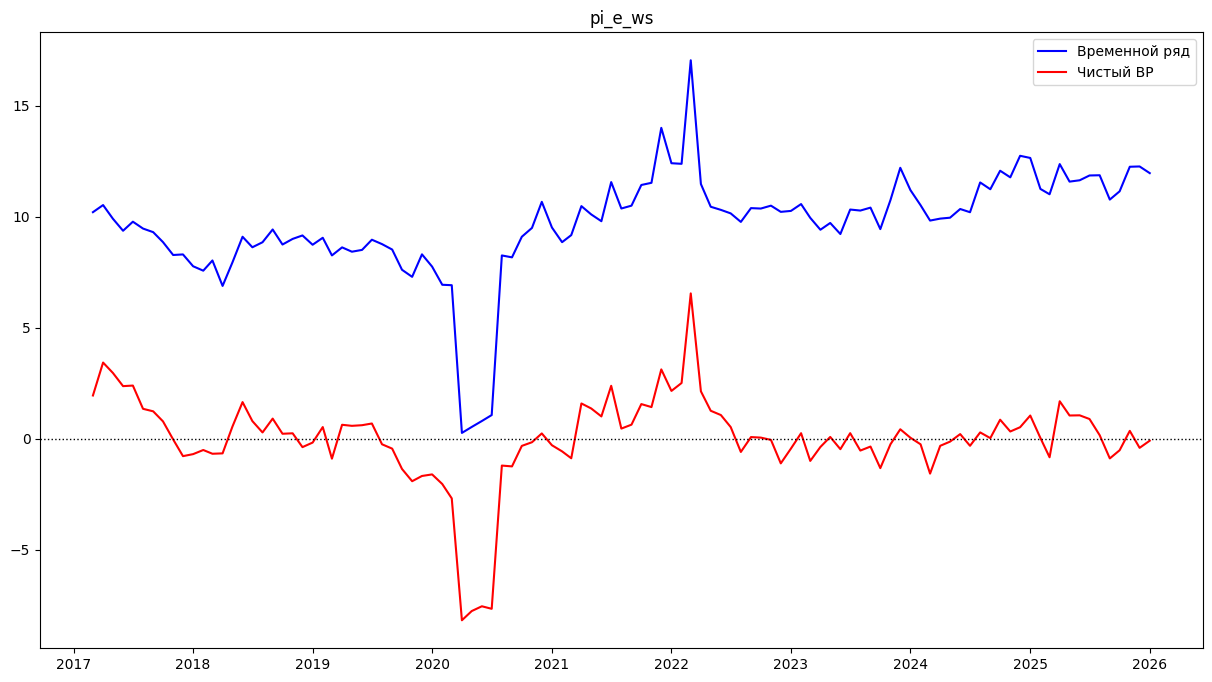

Исходный ряд pi_e_ws оказался стационарным


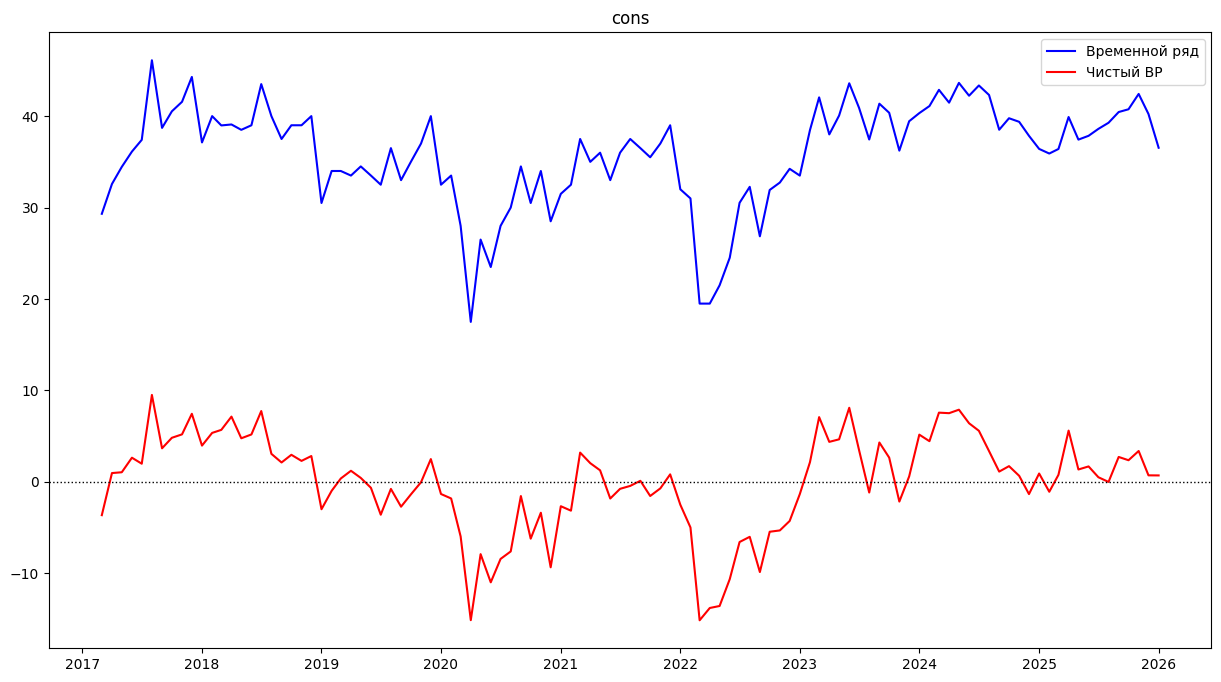

Исходный ряд cons оказался стационарным


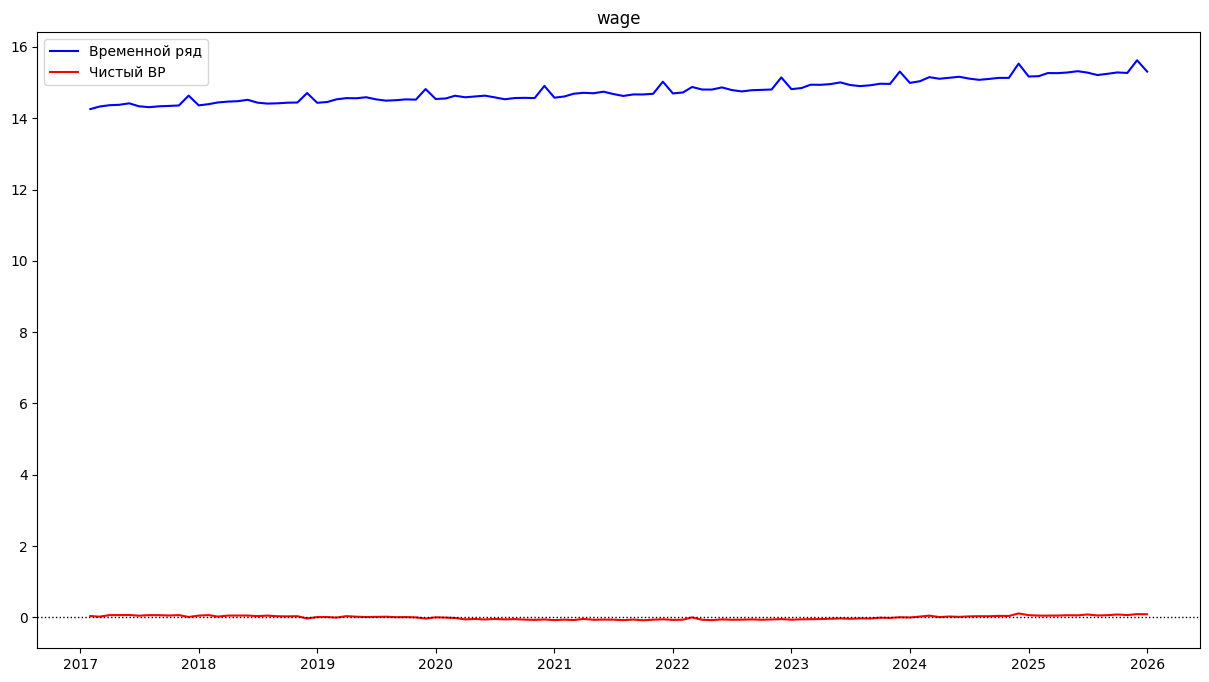

Исходный ряд wage оказался стационарным


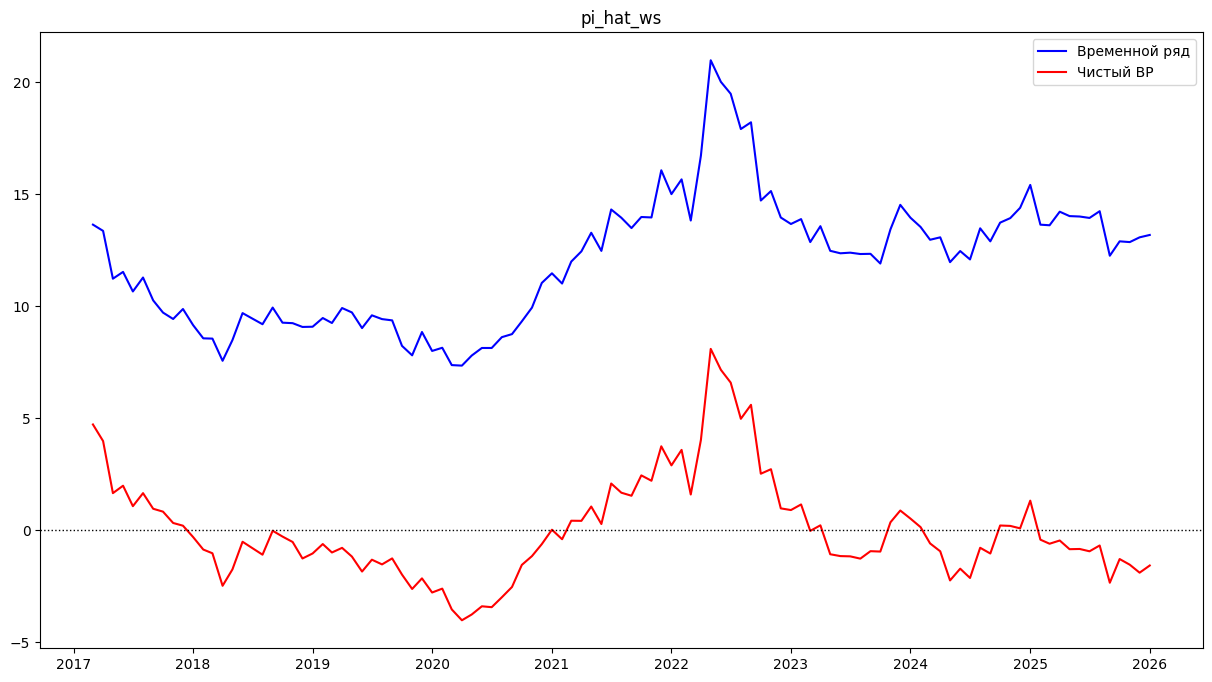

Исходный ряд pi_hat_ws оказался стационарным


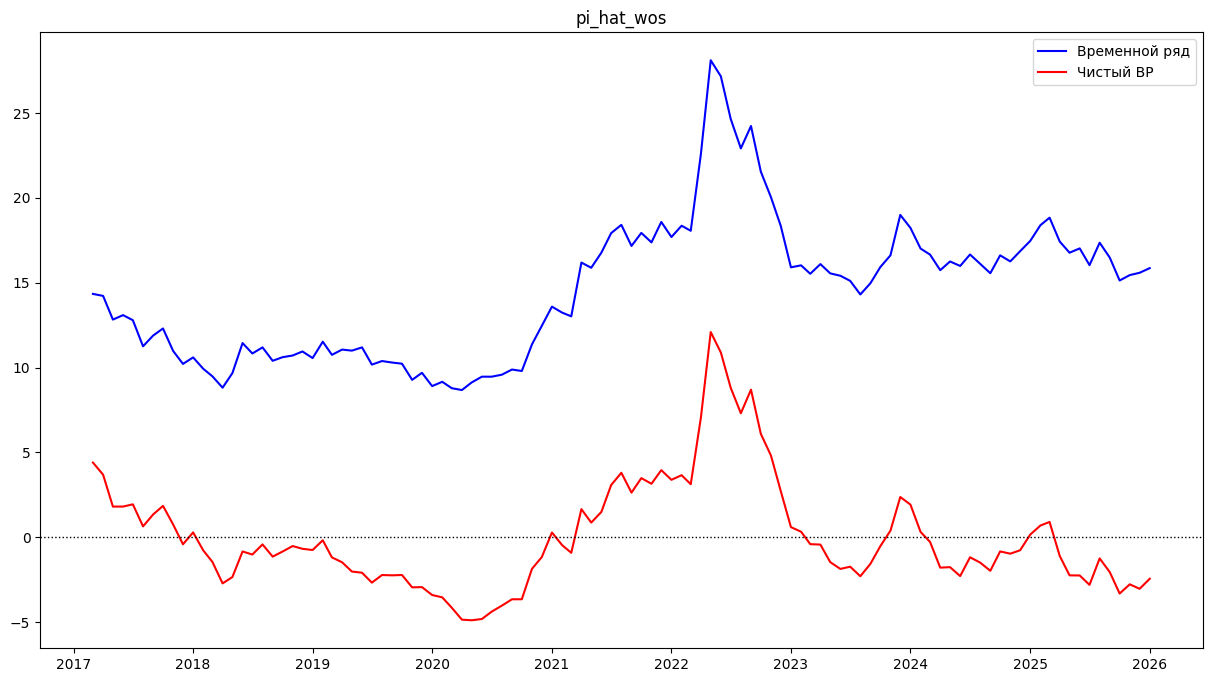

Исходный ряд pi_hat_wos оказался стационарным


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt

import pickle
filename = 'data/monthly_data.pkl'
with open(filename, 'rb') as f:
    monthly_data = pickle.load(f)
sd_df = pd.read_excel('data/pi_e/s_d.xlsx')

from structuralvar import Clean, SVAR_KL
var_spec_pie = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['pi_e', 'pi_e_wos', 'pi_e_ws', 'cons', 'wage', 'pi_hat_ws', 'pi_hat_wos']])
var_spec = Clean(monthly_data.loc[(monthly_data.index > dt(2014, 6, 1)) & (monthly_data.index < dt(2026, 2, 1)),
                                   ['ru_cpi', 'real_ruonia', 'ipi', 'log_deposits_hh', 'log_credits_hh',
                                     'real_brent', 'pi_e', 'pi_e_ws', 'pi_e_wos', 'real_dollar', 'govspend', 'pi_hat_ws', 'pi_hat_wos']])

df, data = var_spec.LOS(use_harmonics=False, only_KPSS = True, hp_filter_map={
                                                                               'ru_cpi': True,
                                                                               'real_rate': False,
                                                                               'm2x_sa_mom': True})
df_pie, data_pie = var_spec_pie.LOS(use_harmonics=False, only_KPSS = True)

covid_start, duration_covid = (data.T.index < dt(2020, 3, 1)).sum(), 5
svo_start, svo_duration = (data.T.index < dt(2022, 2, 1)).sum(), 2

In [2]:
lag = 2

endog_names_pie_general = ['wage', 'cons']
endog_names_pie_special = ['pi_e', 'pi_e_ws', 'pi_e_wos', 'pi_hat_ws', 'pi_hat_wos']
results = {}
for var in endog_names_pie_special:
    df_endog = data_pie.loc[endog_names_pie_general + [var], :].copy()
    df_endog = df_endog.loc[:,df_endog.columns < dt(2020, 4, 1)].copy()   # K×T

    model = SVAR_KL(
        data=df_endog,
        p=lag,
        layout="KL_KxT",
        time_order="chronological",
        add_const=True,
        u_dict = ['шок доходов', 'шок оптимизма', 'шок ОИ'],
        y_dict = ['Объем фонда зарплаты (логарифм)', 'индекс оптимизма', 'инфляционные ожидания']
    ).fit_ols()
    A_hat = model.A_hat
    p = model.p
    K = model.K
    
    unknown_mask = np.array([False, False, True])  

    known_future = data_pie.loc[endog_names_pie_general, :].copy().loc[:,
                        (data_pie.columns > dt(2020, 3, 1)) & (data_pie.columns < dt(2020, 8, 1))]
    res = []
    horizon = known_future.shape[1]
    counter = 0
    future = pd.DataFrame(columns=known_future.columns)
    for i, b in enumerate(unknown_mask):
        
        if not b:
            future.loc[known_future.index.to_list()[i-counter]] = known_future.iloc[i-counter]
        else:
            counter += 1
            future.loc[var] = np.zeros(horizon)    
    for h in range(horizon):
        if h == 0:
            X = model.Z[:, -1]
            
        else:
            
            X = np.hstack([np.array([1]), future.iloc[:, h-1].to_numpy(), X[1:-(K)]])
        y_hat = (A_hat @ X)[unknown_mask]
        future.loc[unknown_mask, future.columns[h]] = y_hat.item()
    results[var] = future.loc[unknown_mask, :]

for var in results:
    data.loc[var,(data.columns > dt(2020, 3, 1)) & (data.columns < dt(2020, 8, 1))] = results[var].to_numpy()

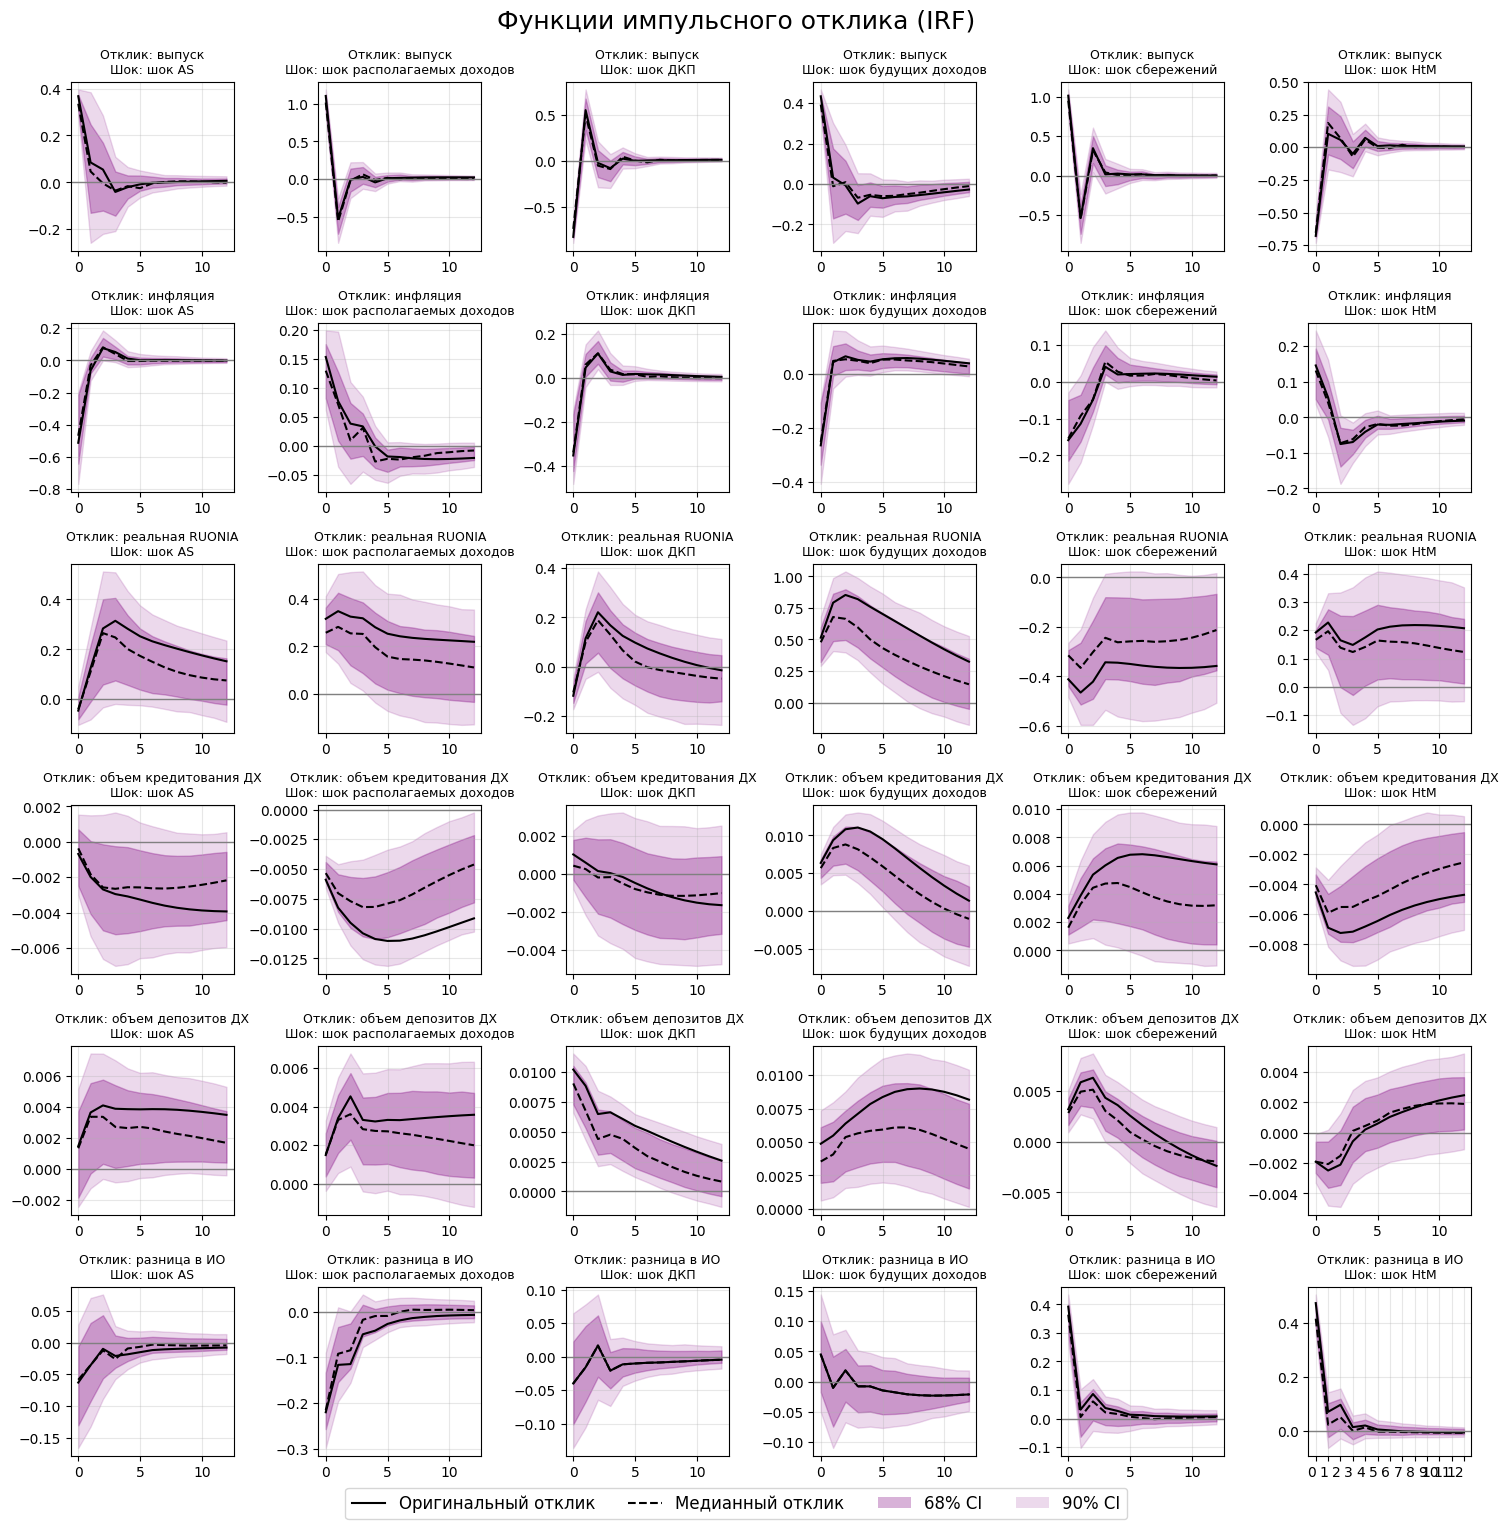

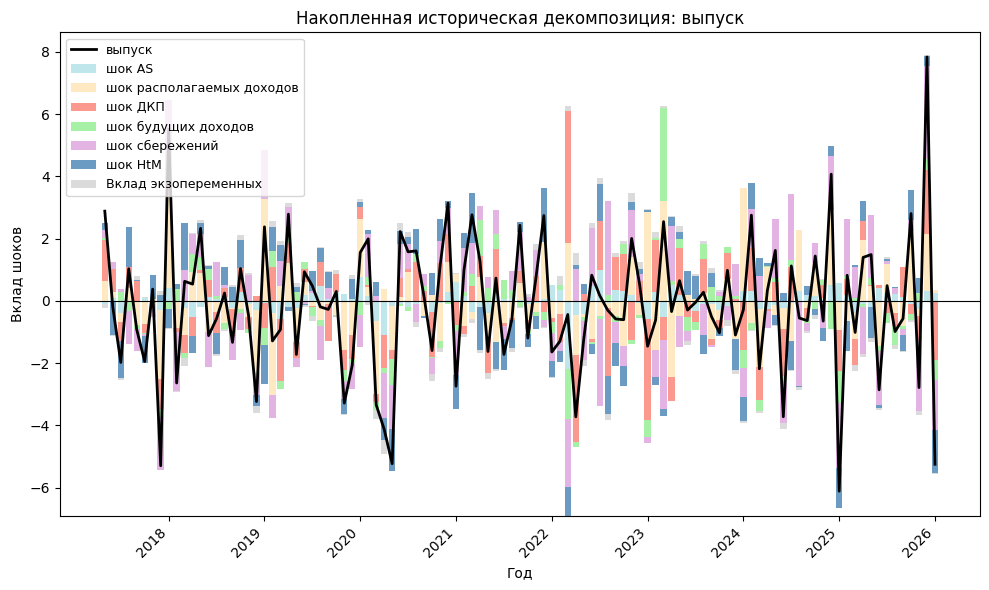

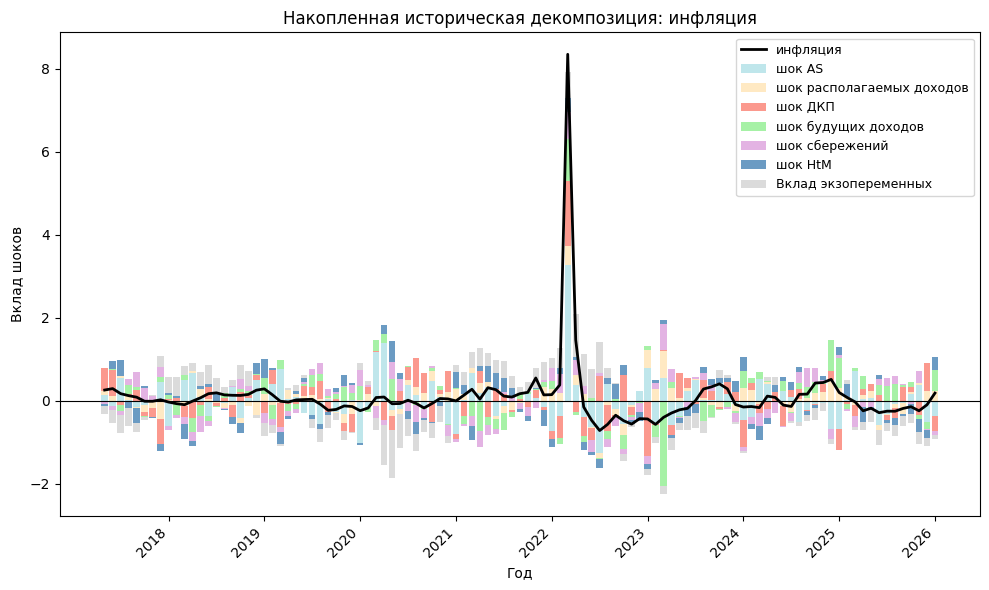

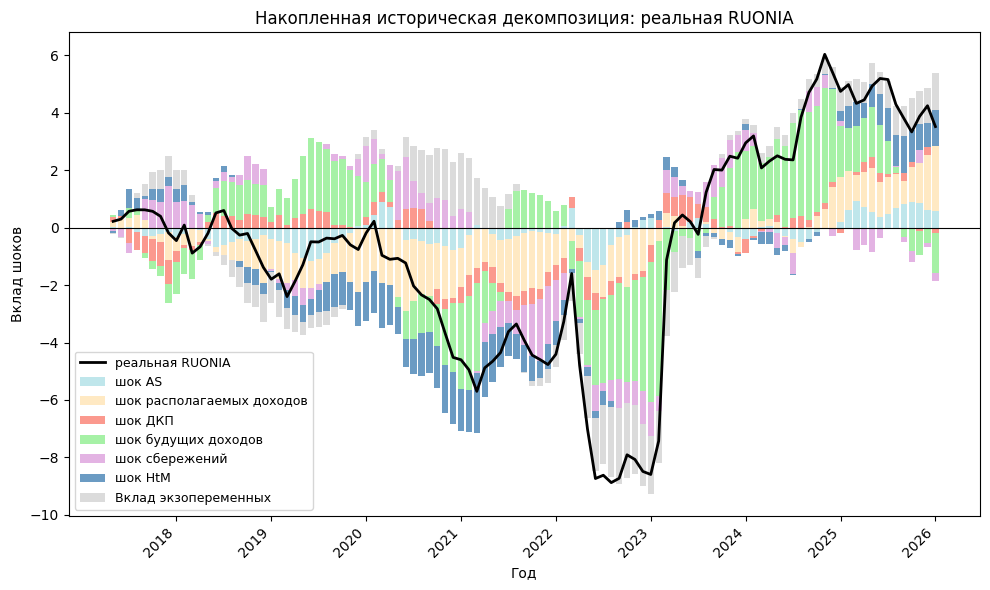

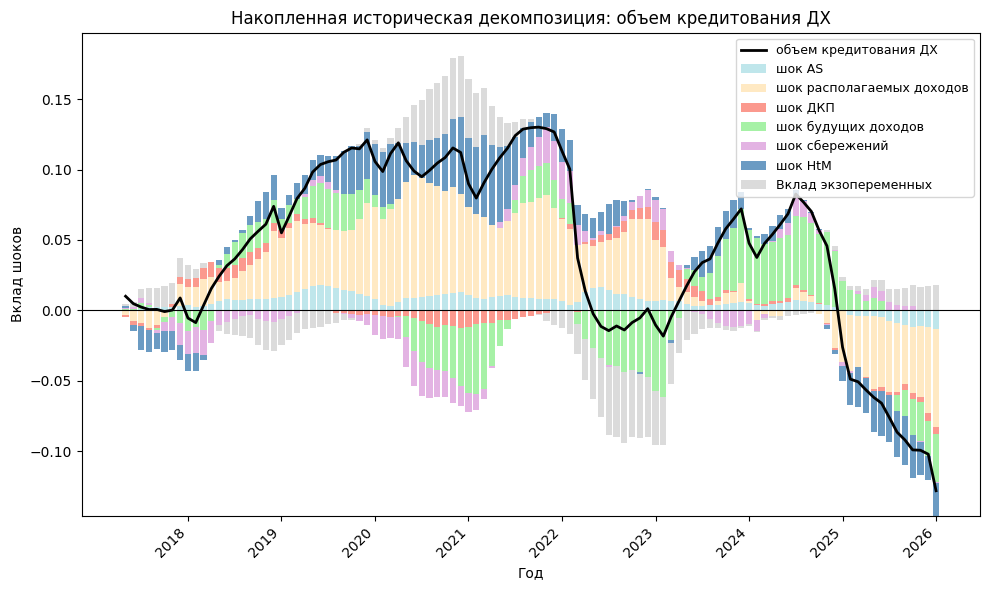

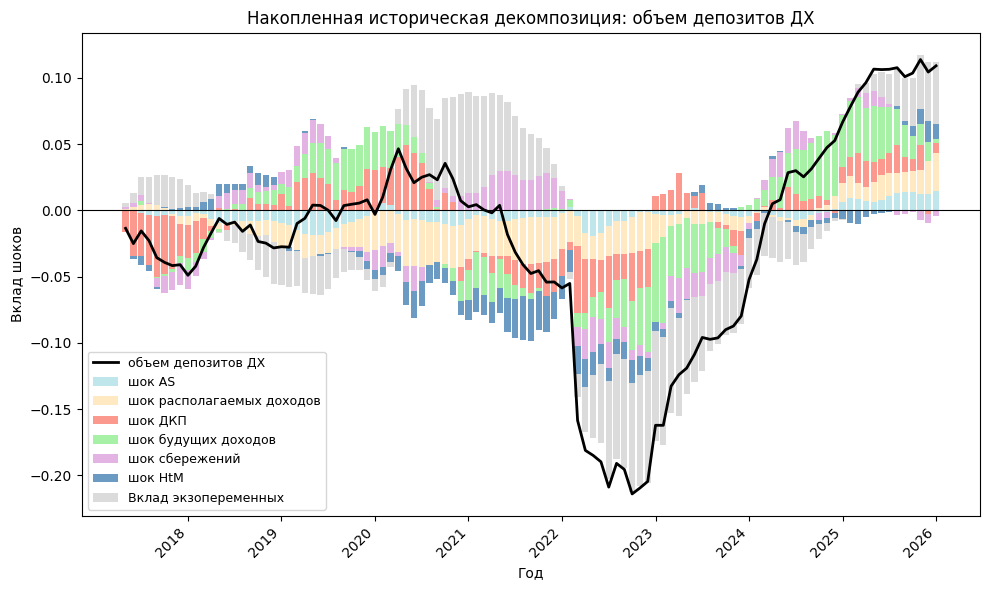

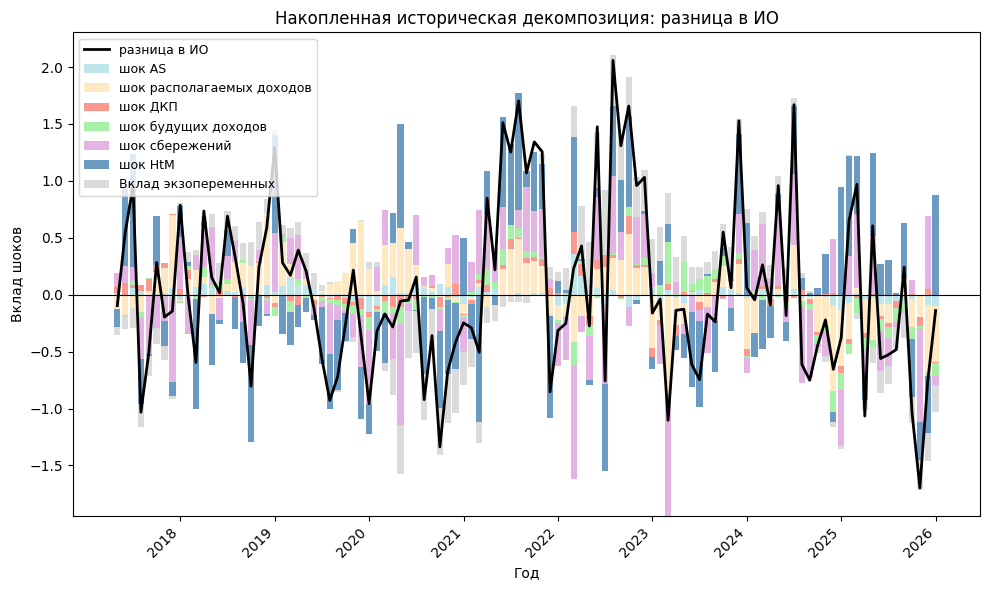

In [3]:
data.loc['pi_e_hete'] = data.loc['pi_e_wos'] - data.loc['pi_e_ws']

short_run_anchor = [
    (0, 0, 1, 0, 1),
    (0, 4, 5, 0, 1),

]
long_run_anchor = [
    (0, 2, 2, 10)
]
short_run_signs = [(0, 1, 2, False, 0, 2),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1.4),
                   (0, 3, 3, True, 0, 1),
                   (0, 0, 0, False, 0, 1),
                   (0, 5, 5, True, 0, 10),
                   (0, 4, 4, True, 0, 20),
                   (0, 2, 3, True, 0, 1),
                   (0, 2, 4, False, 0, 1),
                   (0, 3, 5, False, 0, 10),
                   (0, 2, 1, True, 0, 1),
                   (0, 3, 2, False, 0, 23),
                   (0, 3, 2, False, 1, 20),
                   (0, 3, 2, False, 2, 20),

                   #(0, 4, 3, True, 0, 1),
                   #(0, 1, 4, False, 0, 1),
                   #(0, 1, 4, False, 0, 1),
                   #(0, 5, 2, False, 0, 1),
                   #(1, 5, 5, True, 0, 10),
                   #(0, 5, 4, False, 0, 10),
                   #(0, 5, 3, True, 0, 10)
                   ]
long_run_signs = [
    (0, 3, 5, False, 10),
    (0, 2, 1, True, 10),
    (0, 0, 0, True, 10),
    (0, 0, 1, True,  30),
    #(0, 3, 2, False, 3),
    #(0, 5, 3, True, 3)
]
lag = 2

endog_names = ['ipi', 'ru_cpi', 'real_ruonia', 'log_credits_hh', 'log_deposits_hh', 'pi_e_hete']
exog_names  = ['real_brent']

df_endog = data.loc[endog_names, :]   # K×T
df_exog  = data.loc[exog_names, :]    # K_ex×T

model = SVAR_KL(
    data=df_endog,
    p=lag,
    exog=df_exog,              #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок AS', 'шок располагаемых доходов', 'шок ДКП', 'шок будущих доходов', 'шок сбережений', 'шок HtM'],
    y_dict = ['выпуск', 'инфляция', 'реальная RUONIA', 
              'объем кредитования ДХ', 'объем депозитов ДХ', 'разница в ИО']
).fit_ols()

rr = model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 120
irf0 = model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=12,
                     main_color='purple')


hd = model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)


In [4]:
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]
(share_hd_full*100).astype(float).round(1)

,выпуск,инфляция,реальная RUONIA,объем кредитования ДХ,объем депозитов ДХ,разница в ИО
шок AS,6.7,20.8,7.0,6.5,5.7,3.9
шок располагаемых доходов,23.6,8.6,18.2,30.9,13.8,16.7
шок ДКП,19.1,15.9,6.4,4.0,14.3,3.4
шок будущих доходов,7.3,11.4,29.0,19.8,16.8,4.7
шок сбережений,23.7,10.2,10.9,7.2,9.5,24.8
шок HtM,13.6,9.6,11.4,15.5,7.2,29.5
Вклад экзопеременных,2.6,15.4,14.5,12.8,28.7,13.5
Необъяснено шоками,3.3,8.1,2.6,3.4,4.0,3.5


In [5]:
pd.DataFrame(model.Upsilon).round(2).set_axis(list(model.y_dict.values()), axis = 0).set_axis(list(model.u_dict.values()), axis = 1).to_latex()

'\\begin{tabular}{lrrrrrr}\n\\toprule\n & шок AS & шок располагаемых доходов & шок ДКП & шок будущих доходов & шок сбережений & шок HtM \\\\\n\\midrule\nвыпуск & 0.820000 & 1.420000 & -0.190000 & 0.140000 & 0.350000 & -0.010000 \\\\\nинфляция & -0.630000 & -0.350000 & -0.120000 & 0.440000 & 0.260000 & -0.370000 \\\\\nреальная RUONIA & 5.250000 & 9.380000 & 0.000000 & 9.330000 & -12.620000 & 7.060000 \\\\\nобъем кредитования ДХ & -0.170000 & -0.380000 & -0.030000 & 0.010000 & 0.330000 & -0.240000 \\\\\nобъем депозитов ДХ & 0.120000 & 0.180000 & 0.080000 & 0.190000 & -0.130000 & 0.100000 \\\\\nразница в ИО & -0.360000 & -0.870000 & -0.120000 & -0.300000 & 0.940000 & 0.490000 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [ ]:
import numpy as np
from scipy.optimize import minimize

def check_stationarity(rho):
    """
    Проверяет стационарность AR(p) процесса.
    Корни характеристического полинома должны лежать ВНЕ единичного круга.
    Полином: 1 - rho1*z - rho2*z^2 - ... = 0
    """
    # Коэффициенты полинома: [1, -rho1, -rho2, ..., -rho12]
    coeffs = np.r_[1, -np.array(rho)]
    roots = np.roots(coeffs)
    # Все корни по модулю должны быть > 1
    return np.all(np.abs(roots) > 1.0)

def generate_AR_series(rho, T, burn_in=100):
    """Генерирует кандидатный шок AR(12)"""
    p = len(rho)
    eta = np.random.normal(0, 1, T + burn_in)
    xi = np.zeros(T + burn_in)
    
    for t in range(p, T + burn_in):
        # xi_t = sum(rho_i * xi_{t-i}) + eta_t
        xi[t] = np.sum(rho * xi[t-p:t][::-1]) + eta[t]
    
    return xi[burn_in:]

def orthogonalize_shock(candidate_shock, other_shocks):
    """Проецирует шок на пространство, ортогональное другим шокам"""
    # other_shocks: матрица T x 5
    # candidate_shock: вектор T x 1
    # Метод наименьших квадратов для нахождения проекции
    proj_coef, _, _, _ = np.linalg.lstsq(other_shocks, candidate_shock, rcond=None)
    projection = other_shocks @ proj_coef
    orthogonal_shock = candidate_shock - projection
    return orthogonal_shock

def loss_function(rho, E_other, original_mp_shock, irf_mp, pi_history, pi_target=0.0):
    """
    rho: параметры AR(12) (12 коэффициентов)
    E_other: матрица остальных 5 структурных шоков (T x 5)
    original_mp_shock: исторический шок ДКП (T x 1)
    irf_mp: импульсный отклик инфляции на шок ДКП (вектор, например, 24 месяца)
    pi_history: историческая инфляция (T x 1)
    """
    T = E_other.shape[0]
    
    # 0. ПРОВЕРКА СТАЦИОНАРНОСТИ (Критическое ограничение)
    if not check_stationarity(rho):
        return 1e10  # Большой штраф за нестационарность
    
    # 1. Генерация кандидата
    xi = generate_AR_series(rho, T)
    
    # 2. Ортогонализация (Критерий 1)
    v_raw = orthogonalize_shock(xi, E_other)
    
    # Проверка на вырождение (если шок стал почти нулем после проекции)
    if np.std(v_raw) < 1e-6:
        return 1e10 
    
    # 3. Нормировка (Критерий 2)
    v_new = v_raw / np.std(v_raw)
    
    # 4. Симуляция новых переменных (Критерий 4)
    # Используем свертку с импульсным откликом для оценки вклада шока
    # Вклад = shock * IRF. 
    # Примечание: Для точности лучше использовать полную матрицу MA представления SVAR,
    # но свертка с IRF часто достаточна для линейной аппроксимации.
    
    # Рассчитываем разницу во вкладе шоков
    # convolve возвращает длину T + len(irf) - 1, обрезаем до T
    contrib_old = np.convolve(original_mp_shock, irf_mp, mode='full')[:T]
    contrib_new = np.convolve(v_new, irf_mp, mode='full')[:T]
    
    # Новая инфляция = Старая - Вклад старого шока + Вклад нового шока
    pi_new = pi_history - contrib_old + contrib_new
    
    # 5. Функция потерь (Только инфляция, без штрафа за ставку)
    inflation_loss = np.mean((pi_new - pi_target)**2)
    
    return inflation_loss

# Пример запуска (псевдокод)


In [48]:
irf_mp = model.irf(horizon=model.T)[:, 1, 2]
Us = np.linalg.inv(model.B0inv) @ model.E
U_other = np.delete(Us, 2, axis = 0).T
mp_shock = Us[2, :]
pi_hist = model.Y[1, :]

In [38]:
initial_rho = np.array([0.1]*12)
result = minimize(loss_function, initial_rho, args=(U_other, mp_shock, irf_mp, pi_hist, 0.0), 
                  method='Nelder-Mead', options={'maxiter': 1000})
optimal_rho = result.x

In [49]:
T = U_other.shape[0]
rho = np.array([0]*12)
# 0. ПРОВЕРКА СТАЦИОНАРНОСТИ (Критическое ограничение)
if not check_stationarity(rho):
    print('F')

# 1. Генерация кандидата
xi = generate_AR_series(rho, T)

# 2. Ортогонализация (Критерий 1)
v_raw = orthogonalize_shock(xi, U_other)

# Проверка на вырождение (если шок стал почти нулем после проекции)
if np.std(v_raw) < 1e-6:
    print('f')

# 3. Нормировка (Критерий 2)
v_new = v_raw / np.std(v_raw)

F


In [50]:
v_new

array([ 1.0780833 ,  0.61189373,  0.29583554,  0.07413462,  1.78849583,
       -0.21285101, -0.76518237,  0.143519  ,  1.53506379, -1.01184573,
       -0.97266852, -0.73834271, -0.66321036,  1.09446752, -1.03735902,
        0.0709094 ,  0.57589365,  1.05854424, -0.04462482, -0.20325329,
       -1.52509094,  0.08116937, -0.00786027, -0.70954938,  1.21169581,
       -0.13306652, -0.58448318, -1.48640032, -0.58282212, -0.23518846,
       -0.51929964,  0.03493152, -0.89817544, -0.18194754,  1.08061071,
       -1.40515481,  0.50908096,  1.48154887, -0.76061257, -0.03791313,
        1.98173155, -0.50045236, -0.31732882,  0.04505719, -0.24788952,
        0.28156102,  1.82769021,  0.90616161,  1.4585696 ,  1.19110577,
        0.27593223,  0.56671219,  0.2895236 , -0.21560146, -0.24205921,
        1.44807926, -0.17422876, -0.12105011,  1.18656046,  0.84089051,
       -0.12869236,  0.64866347, -0.14082017, -0.09883396,  0.46663099,
        1.95009285, -0.5448179 , -0.67759985, -1.60939369, -0.78

In [51]:
coeffs = np.r_[1, -np.array(rho)]
roots = np.roots(coeffs)
np.all(np.abs(roots) > 1.0)

np.False_

In [55]:
roots.shape

(12,)

In [36]:
import numpy as np
from scipy.signal import lfilter

def pacf_to_ar(pacf):
    """
    Преобразует частичные автокорреляции (PACF) в коэффициенты AR
    через рекурсию Дурбина-Левинсона.
    pacf: массив частичных автокорреляций [phi_11, phi_22, ..., phi_pp]
    returns: массив коэффициентов AR [rho_1, rho_2, ..., rho_p]
    """
    p = len(pacf)
    ar_coef = np.zeros(p)
    
    for k in range(p):
        phi_kk = pacf[k]
        if k == 0:
            ar_coef[k] = phi_kk
        else:
            # Обновляем предыдущие коэффициенты
            ar_coef[:k] = ar_coef[:k] - phi_kk * ar_coef[:k][::-1]
            ar_coef[k] = phi_kk
    return ar_coef

def generate_stationary_ar_coef(p, n_draws=1000):
    """
    Генерирует n_draws наборов стационарных AR(p) коэффициентов.
    """
    ar_sets = []
    for _ in range(n_draws):
        # PACF всегда в (-1, 1) для стационарного процесса
        pacf = np.random.uniform(-0.95, 0.95, size=p)  # небольшой запас от границ
        rho = pacf_to_ar(pacf)
        ar_sets.append(rho)
    return np.array(ar_sets)

# Пример: сгенерировать 100 наборов AR(12) коэффициентов
rho_sets = generate_stationary_ar_coef(p=12, n_draws=100)
print(f"Сгенерировано {len(rho_sets)} наборов коэффициентов")
print(f"Пример первого набора: {rho_sets[0]}")

Сгенерировано 100 наборов коэффициентов
Пример первого набора: [-0.46038599  0.63533984 -0.76749707  0.44737013  1.02225501 -0.62734753
  0.95710526  0.55561606 -0.52242248  0.65175916 -0.36970601 -0.81290963]


In [18]:
share_hd_full = pd.DataFrame(columns=list(model.y_dict.values()))
for i in range(model.K):
    share_hd = hd[i].copy()
    share_hd.loc['Необъяснено шоками'] = share_hd.iloc[0] - share_hd.iloc[1:].sum(axis = 0)
    share_hd = share_hd.abs().copy()
    share_hd.iloc[0] = share_hd.iloc[1:].sum(axis = 0)
    share_array = share_hd.sum(axis=1)
    share_hd_full.iloc[:,i] = share_array.iloc[1:]/share_array.iloc[0]
(share_hd_full*100).astype(float).round(1)

,выпуск,инфляция,реальная RUONIA,объем кредитования ДХ,объем депозитов ДХ,разница в ИО
шок AS,10.5,14.4,19.8,31.3,17.9,22.6
шок располагаемых доходов,2.9,15.9,8.8,3.0,3.0,8.0
шок ДКП,7.7,24.4,17.1,17.5,22.9,11.8
шок спроса на кредиты,34.5,6.1,14.1,8.5,7.8,2.8
шок спроса на депозиты,30.7,7.0,12.8,4.8,7.1,10.6
шок HtM,8.4,9.4,11.9,19.1,8.5,27.3
Вклад экзопеременных,2.3,15.8,13.3,12.7,28.7,13.8
Необъяснено шоками,3.0,7.1,2.1,3.1,4.0,3.1


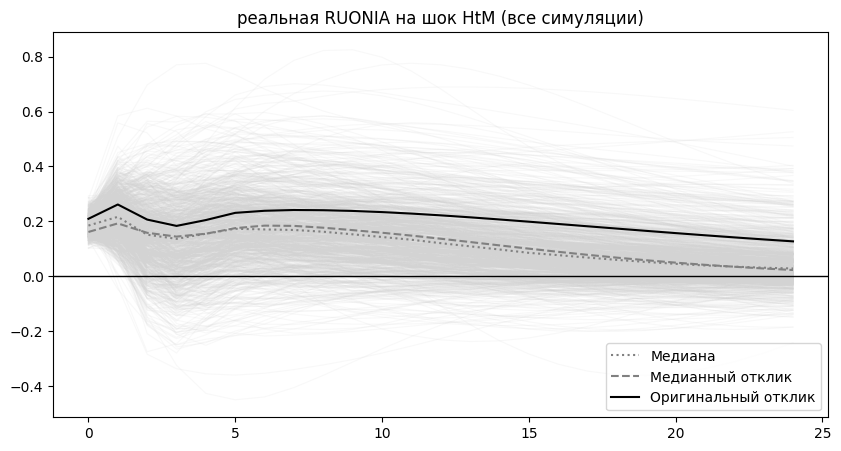

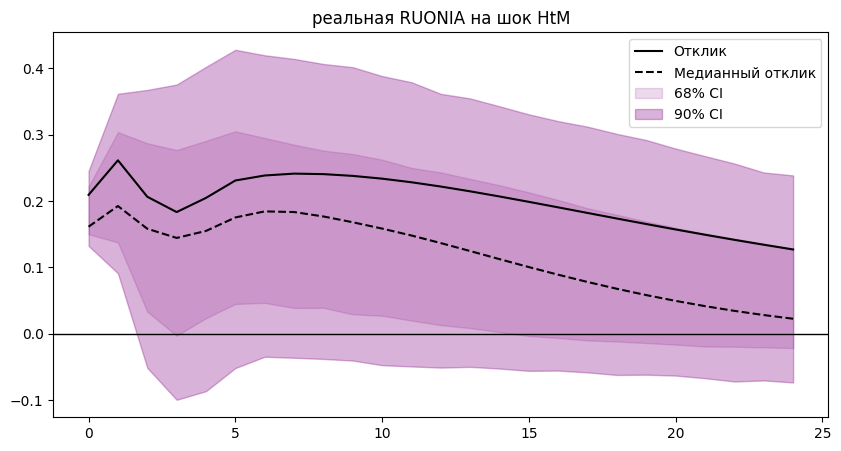

In [6]:
model.plot_single_irf(irf_sims,
                'real_ruonia',
                'шок HtM',
                'purple',
                plot_simulations = True,
                horizon=24,
                cumm = False)